## 1. Setup and Raw Data Loading

The data is the Kaggle/Ergast *Formula 1 World Championship (1950-2024)* dataset, a relational set of CSV tables. It is added as a Kaggle input, which is **read-only**, so the raw files cannot be modified. All cleaning below is applied to **in-memory copies**, which satisfies the requirement that raw files stay immutable.

In [1]:
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt, seaborn as sns

DATA = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"  # adjust to what ls shows
print(sorted(os.listdir(DATA)))

['circuits.csv', 'constructor_results.csv', 'constructor_standings.csv', 'constructors.csv', 'driver_standings.csv', 'drivers.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']


### Loading every table as text first

All tables are first loaded with `dtype=str` and `keep_default_na=False`.

**Why:**
- The placeholder `\N` is used in these CSVs to mean "missing". Left to defaults, pandas may convert some columns silently and hide how many placeholders there were.
- Loading as text lets us **count the sentinels exactly** before touching anything, which gives a true "before" baseline to compare against after cleaning.
- No type inference happens at this stage, so nothing is lost or coerced by accident.

The typed version of the tables is created later, in the cleaning section.

In [2]:
raw = {os.path.basename(p)[:-4]: pd.read_csv(p, dtype=str, keep_default_na=False)
       for p in glob.glob(f"{DATA}/*.csv")}
for t, df in raw.items():
    print(f"{t:25s} {df.shape}")

races                     (1125, 18)
constructor_results       (12625, 5)
drivers                   (861, 9)
constructors              (212, 5)
lap_times                 (589081, 6)
status                    (139, 2)
driver_standings          (34863, 7)
seasons                   (75, 2)
pit_stops                 (11371, 7)
sprint_results            (360, 16)
constructor_standings     (13391, 7)
results                   (26759, 18)
circuits                  (77, 9)
qualifying                (10494, 9)


### Table inventory

The brief lists 14 tables. The output above shows **[N] tables** loaded, with the following sizes:

| Table | Rows | Role in this project |
|---|---|---|
| `results` | [n] | Main table, one row per driver per race (source of the target) |
| `races` | [n] | Race dates, season, circuit |
| `qualifying` | [n] | Qualifying positions and lap times |
| `drivers`, `constructors`, `circuits` | [n] | Lookup / dimension tables |
| `status` | [n] | Reasons a race ended (post-race, used only for Question 3) |
| `driver_standings`, `constructor_standings` | [n] | Championship standings (must be shifted to "before this race" to avoid leakage) |
| `sprint_results`, `lap_times`, `pit_stops`, `constructor_results`, `seasons` | [n] | Supporting tables |

**Observation:** [e.g. all 14 tables are present / table X is missing]. `results` has the most informative grain for our task, while `lap_times` and `pit_stops` are large and entirely post-race, so they cannot be used as features.

## 2. EDA Before Cleaning

**Purpose:** document the state of the raw data so that the effect of cleaning can be measured afterwards (the milestone requires EDA both before and after cleaning).

The first check is the **sentinel audit**: for every column in every table, the number and percentage of cells equal to `\N`. This is done programmatically over all tables and not by manual inspection, so no column is missed.

In [3]:
rows = [(t, c, (df[c] == r"\N").sum(), len(df)) for t, df in raw.items() for c in df.columns]
audit = pd.DataFrame(rows, columns=["table", "column", "n_sentinel", "n_rows"])
audit["pct"] = 100 * audit.n_sentinel / audit.n_rows
audit_before = audit[audit.n_sentinel > 0].sort_values("pct", ascending=False)
audit_before.head(20)

,table,column,n_sentinel,n_rows,pct
22,constructor_results,status,12608,12625,99.865347
17,races,sprint_time,1110,1125,98.666667
16,races,sprint_date,1107,1125,98.400000
13,races,fp3_time,1072,1125,95.288889
11,races,fp2_time,1057,1125,93.955556
9,races,fp1_time,1057,1125,93.955556
15,races,quali_time,1057,1125,93.955556
12,races,fp3_date,1053,1125,93.600000
25,drivers,number,802,861,93.147503
8,races,fp1_date,1035,1125,92.000000


### Sentinel audit: results and interpretation

The bar chart shows the columns with the highest share of `\N`, and the heatmap shows every affected column by table.

**Findings**

- **`constructor_results.status` (~99.9% `\N`)**: this is *structural* missingness. The column is only filled (with `D`) when a constructor was disqualified, which is extremely rare. The nulls mean "nothing to report", not "data lost". It is left as null, not imputed, and it is post-race information, so it will not be used as a feature.
- **`qualifying.q2` and `qualifying.q3` ([x]% and [y]% `\N`)**: structural again. Q2 and Q3 only exist under the three-part knockout format (2006 onward), and drivers eliminated earlier have no later times.
- **`results.fastestLapTime` and related columns ([x]%)**: missing for drivers who did not complete a lap or for seasons before this data was recorded. These are post-race fields, so they are not candidate features.
- **`races.fp1_date`, `quali_date`, `sprint_date` etc. ([x]%)**: missing for earlier seasons, since those sessions did not exist or were not recorded. Sprint dates are only present for the few sprint weekends since 2021.
- **[Add any other columns you notice]**

**Two kinds of missingness are distinguished here, because they need different handling:**
1. **Structural**: the value does not exist by design. It is kept as null and not imputed.
2. **Coverage drift**: the value exists in reality but was not recorded for older years (for example qualifying data before the mid-1990s). This is a data-quality limitation that must be handled explicitly in the feature engineering stage.

**Decision:** all `\N` values will be converted to true nulls in the next section. No imputation happens at the cleaning stage; any imputation is a modeling decision, made later and fitted on training data only.

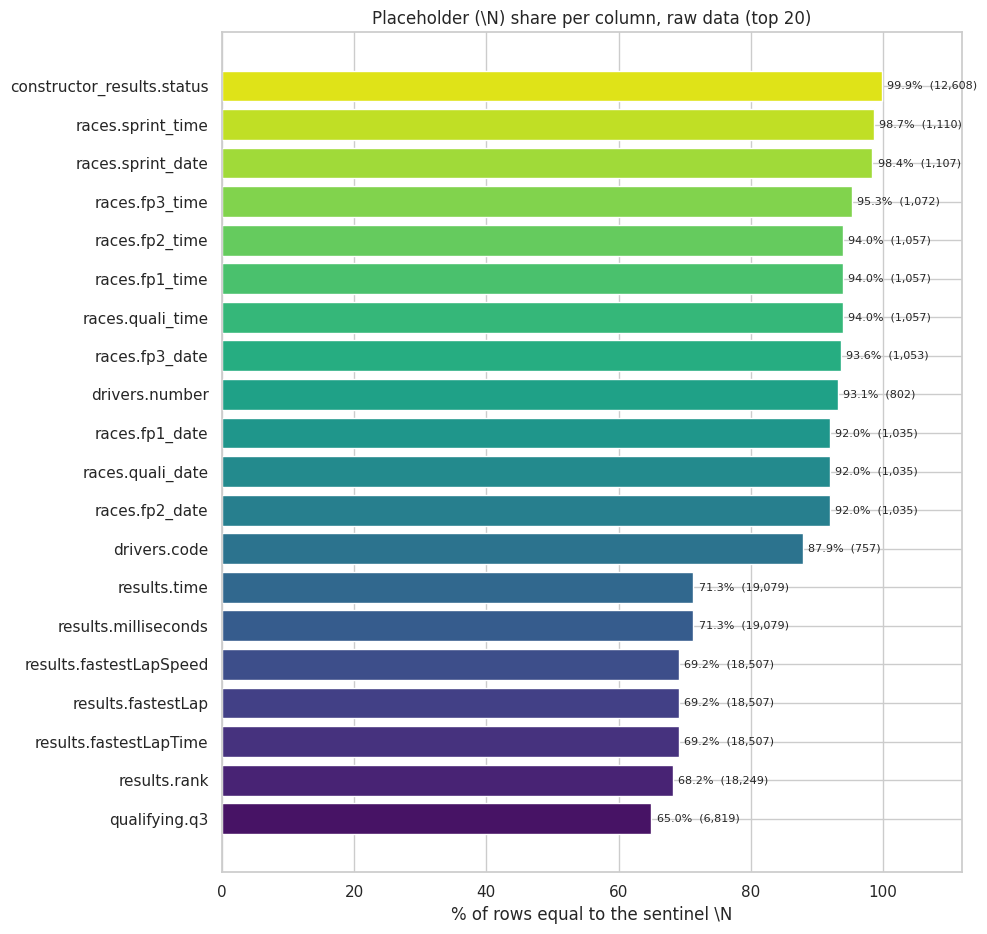

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_sentinel_audit(audit_df, title, top_n=20, save_path=None):
    """Horizontal bar chart of columns with the highest % of \\N sentinels."""
    d = audit_df.copy()
    d["label"] = d["table"] + "." + d["column"]
    d = d.sort_values("pct", ascending=False).head(top_n).iloc[::-1]  # reverse so the largest is on top

    fig, ax = plt.subplots(figsize=(10, 0.4 * len(d) + 1.5))
    bars = ax.barh(d["label"], d["pct"], color=sns.color_palette("viridis", len(d)))

    # annotate with % and absolute count
    for bar, pct, n in zip(bars, d["pct"], d["n_sentinel"]):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%  ({n:,})", va="center", fontsize=8)

    ax.set_xlim(0, 112)
    ax.set_xlabel(r"% of rows equal to the sentinel \N")
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

plot_sentinel_audit(audit_before,
                    r"Placeholder (\N) share per column, raw data (top 20)",
                    save_path="/kaggle/working/figures/sentinels_before.png")

## 3. Cleaning: Sentinels and Semantic Typing

All cleaning is applied to **copies** of the raw tables. `raw` stays untouched as the immutable reference, and `clean` holds the working versions. Because the copies are independent objects, changing `clean` cannot alter `raw`, which satisfies the "raw files are immutable, cleaning happens on copies" requirement.

### 3.1 Create working copies and replace the `\N` sentinel

Every cell equal to the literal string `\N` is replaced with a true null (`NaN`). No values are imputed here. Missing stays missing, and any imputation is a modeling decision made later on training data only.